$$ \text{Случайная величина имеет экспоненциальный закон распределения:} $$

$$ p(x) = \begin{cases}
  e^{-x}, & x \geq 0, \\
  0, &  x < 0
\end{cases} $$

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb
import seaborn as sns
from tabulate import tabulate
import pandas as pd


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Выборка объёма n = 25:

In [141]:
class ExponentialDistribution:
    """Экспоненциальное распределение с параметром λ = 1"""
    
    @staticmethod
    def pdf(x):
        """Функция плотности вероятности"""
        return np.exp(-x) if x >= 0 else 0
    
    @staticmethod
    def cdf(x):
        """Интегральная функция распределения"""
        return 1 - np.exp(-x) if x >= 0 else 0
    
    @staticmethod
    def quantile(y):
        """Квантильная функция (обратная к функции распределения)"""
        return -np.log(1 - y)

# Генерация выборки
np.random.seed(42)
n = 25
exp_dist = ExponentialDistribution()

uniform_sample = np.random.uniform(size=n)
sample = np.array([exp_dist.quantile(u) for u in uniform_sample])
sorted_sample = np.sort(sample)

df = pd.DataFrame({
    'Исходная выборка': sample,
    'Вариационный ряд': sorted_sample
})

df = df.round(6)

print("=" * 50)
print("ВЫБОРКА".center(50))
print("=" * 50)
print(df)


                     ВЫБОРКА                      
    Исходная выборка  Вариационный ряд
0           0.469268          0.020799
1           3.010121          0.059839
2           1.316746          0.150235
3           0.912943          0.169596
4           0.169625          0.169625
5           0.169596          0.200679
6           0.059839          0.202611
7           2.011231          0.238688
8           0.919082          0.344223
9           1.231250          0.345516
10          0.020799          0.362754
11          3.503557          0.456277
12          1.786430          0.469268
13          0.238688          0.565537
14          0.200679          0.608935
15          0.202611          0.743928
16          0.362754          0.912943
17          0.743928          0.919082
18          0.565537          0.946371
19          0.344223          1.231250
20          0.946371          1.316746
21          0.150235          1.786430
22          0.345516          2.011231
23          0

### a) Мода, медиана, размах, коэффициент асимметрии

In [142]:
def central_moment(data, k):
    """Вычисление k-го центрального момента"""
    return np.mean((data - np.mean(data))**k)

# Статистики
sample_mean = np.mean(sorted_sample)
sample_median = np.median(sorted_sample)
sample_range = np.ptp(sorted_sample)

unique_values = len(set(sorted_sample))
mode_value = "    Значения уникальны"

m2 = central_moment(sorted_sample, 2)
m3 = central_moment(sorted_sample, 3)
sample_skewness = m3 / m2**1.5 if m2 > 0 else 0

stats_data = [
    ["Среднее", f"{sample_mean:.6f}"],
    ["Медиана", f"{sample_median:.6f}"],
    ["Размах", f"{sample_range:.6f}"],
    ["Коэффициент асимметрии", f"{sample_skewness:.6f}"],
    ["Мода", mode_value]
]

print("\n" + "="*60)
print("СТАТИСТИКИ ВЫБОРКИ".center(60))
print("="*60)

df_stats = pd.DataFrame(stats_data, columns=["Статистика", "Значение"])
print(df_stats.to_string(index=False))

print("="*60)


                     СТАТИСТИКИ ВЫБОРКИ                     
            Статистика               Значение
               Среднее               0.829850
               Медиана               0.469268
                Размах               3.482758
Коэффициент асимметрии               1.699822
                  Мода     Значения уникальны


### b) Эмпирическая функция распределения, гистограмма и boxplot

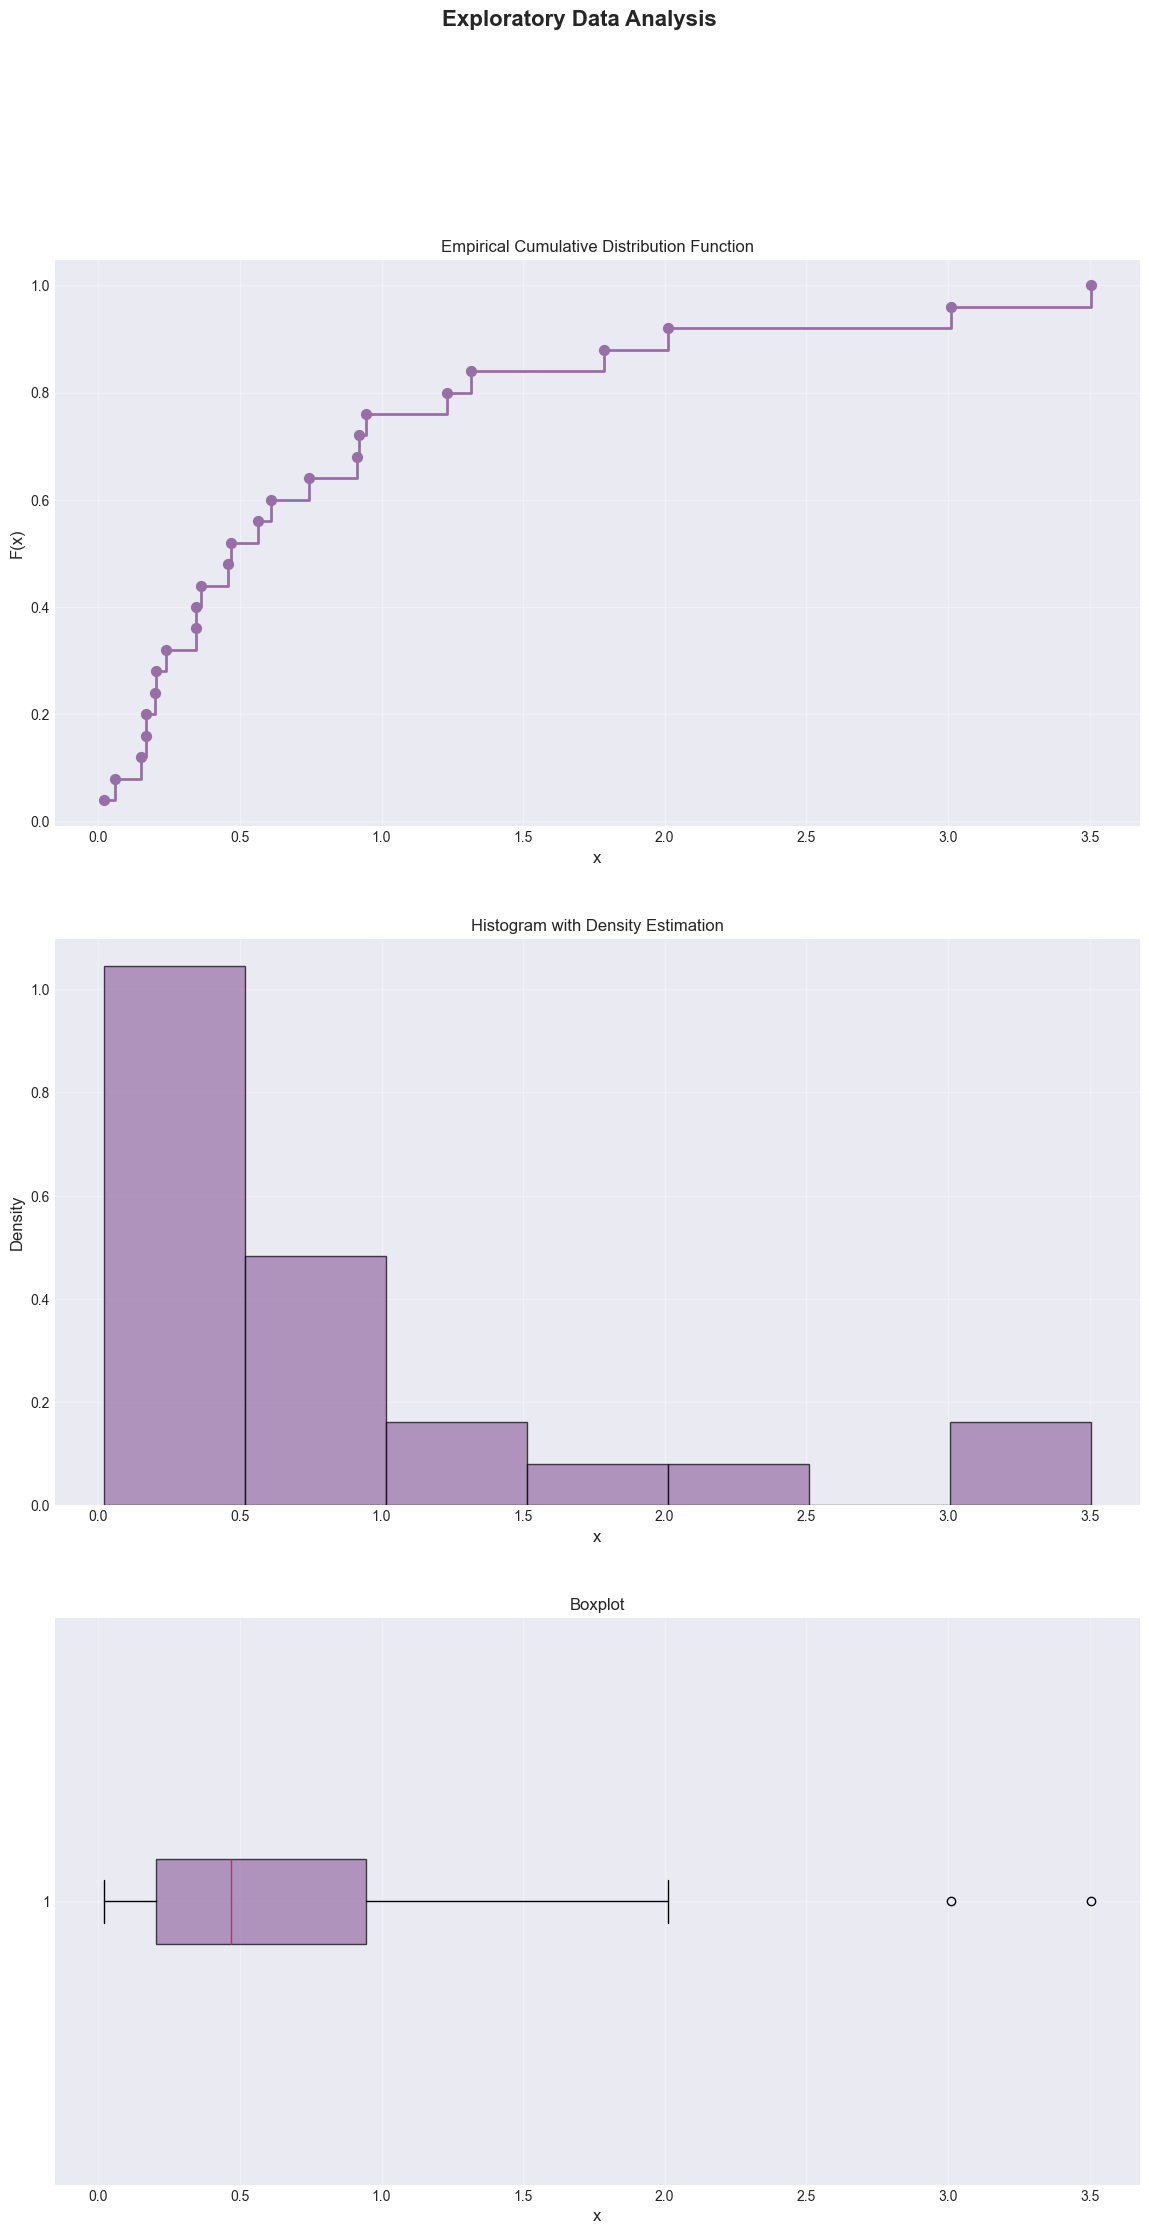

In [143]:
fig, axes = plt.subplots(3, figsize=(14, 25))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight='bold')

# Empirical CDF
ax1 = axes[0]
ax1.step(sorted_sample, np.arange(1, n+1)/n, 
         where='post', linewidth=2, color='#976FA7')
ax1.scatter(sorted_sample, np.arange(1, n+1)/n, 
           color='#976FA7', s=50, zorder=5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('F(x)', fontsize=12)
ax1.set_title('Empirical Cumulative Distribution Function', fontsize=12)
ax1.grid(True, alpha=0.3)

# Histogram
ax2 = axes[1]
ax2.hist(sorted_sample, bins='auto', density=True, 
         alpha=0.7, color="#976FA7", edgecolor='black')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Histogram with Density Estimation', fontsize=12)
ax2.grid(True, alpha=0.3)

# Boxplot
ax3 = axes[2]
box = ax3.boxplot(sorted_sample, vert=False, patch_artist=True)
box['boxes'][0].set_facecolor("#976FA7")
box['boxes'][0].set_alpha(0.7)
box['whiskers'][0].set_color('black')
box['whiskers'][1].set_color('black')
box['medians'][0].set_color('#A23B72')
ax3.set_xlabel('x', fontsize=12)
ax3.set_title('Boxplot', fontsize=12)
ax3.grid(True, alpha=0.3)

### c) Сравнение оценки плотности распределения среднего арифметического элементов выборки, полученной с помощью ЦПТ, с бутстраповской оценкой

C:\Users\astaf\AppData\Local\Temp\ipykernel_22672\1648310412.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(x_norm, y_norm, 'r-', linewidth=2, label='Нормальная аппроксимация (ЦПТ)', color='#A23B72')


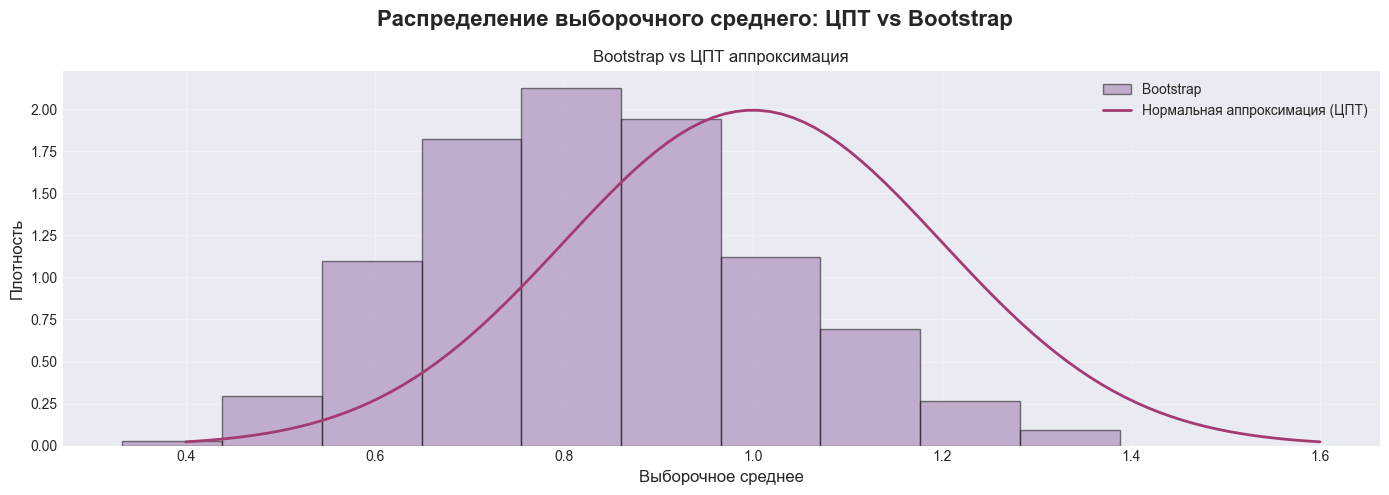

In [147]:
n_bootstrap = 1000

# Теоретическое распределение выборочного среднего (по ЦПТ)
mu_theoretical = 1  # матожидание Exp(1)
sigma_theoretical = 1 / np.sqrt(n)  # стандартная ошибка

# Bootstrap распределение
bootstrap_means = np.array([
    np.mean(np.random.choice(sample, size=n, replace=True))
    for _ in range(n_bootstrap)
])

# Построение графиков сравнения
fig, ax2 = plt.subplots(1, figsize=(14, 5))
fig.suptitle("Распределение выборочного среднего: ЦПТ vs Bootstrap", 
             fontsize=16, fontweight='bold')

# Сравнение с нормальной аппроксимацией
ax2.hist(bootstrap_means, bins=10, density=True, 
         alpha=0.5, color='#976FA7', edgecolor='black', label='Bootstrap')
x_norm = np.linspace(mu_theoretical - 3*sigma_theoretical, 
                     mu_theoretical + 3*sigma_theoretical, 100)
y_norm = stats.norm.pdf(x_norm, mu_theoretical, sigma_theoretical)
ax2.plot(x_norm, y_norm, 'r-', linewidth=2, label='Нормальная аппроксимация (ЦПТ)', color='#A23B72')
ax2.set_xlabel('Выборочное среднее', fontsize=12)
ax2.set_ylabel('Плотность', fontsize=12)
ax2.set_title('Bootstrap vs ЦПТ аппроксимация', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### d) Бутстраповская оценка плотности распределения коэффициента ассиметрии и оценка вероятности того, чтокоэффициент ассиметрии будет меньше 1

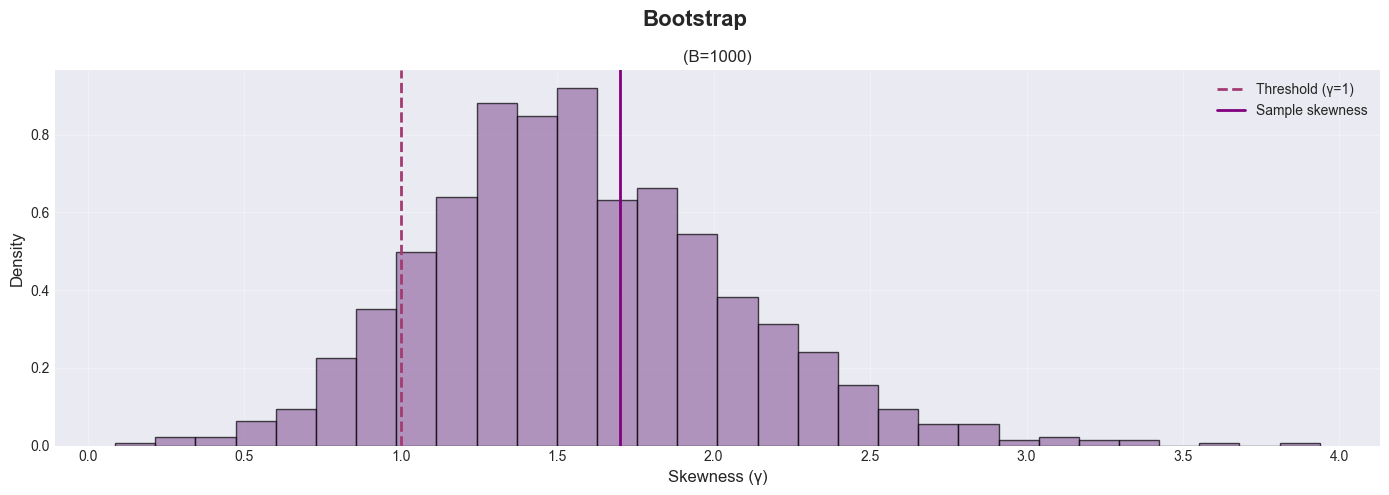

P(Skewness < 1): 0.109000
Sample Skewness: 1.699822


In [149]:
def calculate_skewness(data):
    """Calculate sample skewness"""
    m2 = np.mean((data - np.mean(data))**2)
    m3 = np.mean((data - np.mean(data))**3)
    return m3 / m2**1.5 if m2 > 0 else 0


bootstrap_skewness = np.array([
    calculate_skewness(np.random.choice(sample, size=n, replace=True))
    for _ in range(n_bootstrap)
])

prob_skew_less_1 = np.mean(bootstrap_skewness < 1)

fig, ax1 = plt.subplots(1, figsize=(14, 5))
fig.suptitle("Bootstrap", fontsize=16, fontweight='bold')


ax1.hist(bootstrap_skewness, bins=30, density=True, 
         alpha=0.7, color='#976FA7', edgecolor='black')
ax1.axvline(x=1, color='#A23B72', linestyle='--', linewidth=2, label='Threshold (γ=1)')
ax1.axvline(x=sample_skewness, color='purple', linestyle='-', linewidth=2, label='Sample skewness')
ax1.set_xlabel('Skewness (γ)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title(f'(B={n_bootstrap})', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

skewness_stats = pd.DataFrame({
    "Sample Skewness": [f"{sample_skewness:.6f}"],
    "P(Skewness < 1)": [f"{prob_skew_less_1:.6f}"]
})

print("P(Skewness < 1):", f"{prob_skew_less_1:.6f}")
print("Sample Skewness:", f"{sample_skewness:.6f}")


### e) Сравнение плотности распределения медианы выборки с бутстраповской оценкой этой плотности

C:\Users\astaf\AppData\Local\Temp\ipykernel_22672\1978806.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(x_median, y_median_theor, 'r-', linewidth=2, label='Theoretical', color='#A23B72')


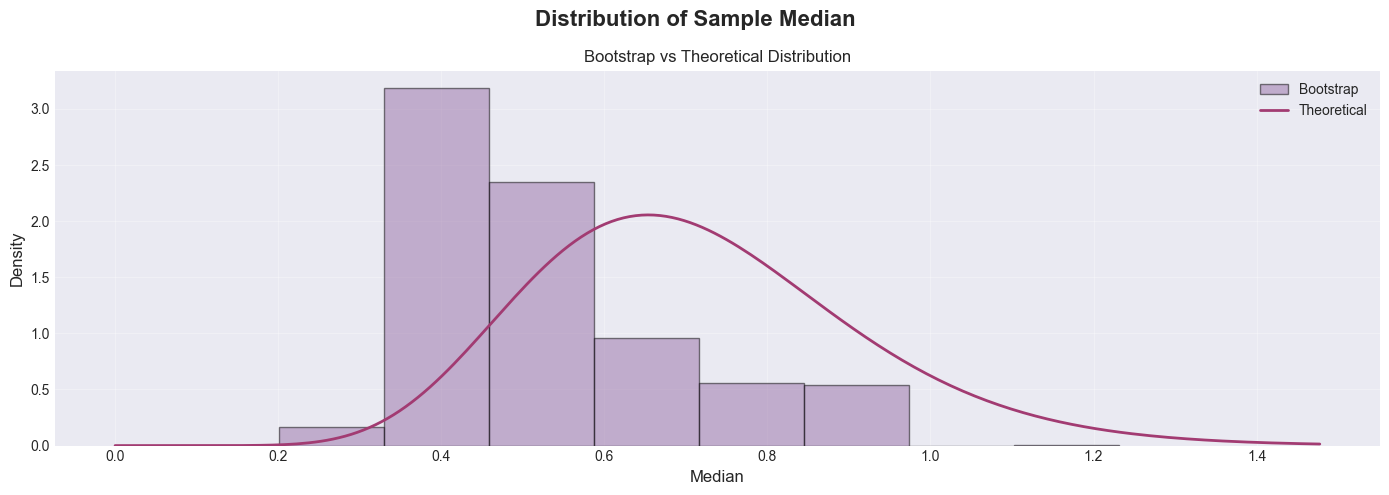

In [150]:
def median_pdf(x, n, dist):
    """PDF of the median for continuous distribution"""
    k = n // 2 + 1 
    return (n * dist.pdf(x) * comb(n-1, k-1) * 
            (1 - dist.cdf(x))**(n-k) * dist.cdf(x)**(k-1))


bootstrap_medians = np.array([
    np.median(np.random.choice(sample, size=n, replace=True))
    for _ in range(n_bootstrap)
])


x_median = np.linspace(0, max(bootstrap_medians)*1.2, 200)
y_median_theor = np.array([median_pdf(xi, n, exp_dist) for xi in x_median])

fig, ax2 = plt.subplots(1, figsize=(14, 5))
fig.suptitle("Distribution of Sample Median", fontsize=16, fontweight='bold')


ax2.hist(bootstrap_medians, bins=8, density=True, 
         alpha=0.5, color='#976FA7', edgecolor='black', label='Bootstrap')
ax2.plot(x_median, y_median_theor, 'r-', linewidth=2, label='Theoretical', color='#A23B72')
ax2.set_xlabel('Median', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Bootstrap vs Theoretical Distribution', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()